# Task 4 — Neural Machine Translation with Attention

## 1. Setup

In [5]:
from __future__ import annotations

import copy
import random
import re
import time
from collections import Counter
from functools import partial
from itertools import zip_longest
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from gensim.models import Word2Vec
from nltk.translate.bleu_score import SmoothingFunction, corpus_bleu
from nltk.translate.chrf_score import corpus_chrf, sentence_chrf
from torch import nn
from torch.nn.utils.rnn import (
    pack_padded_sequence,
    pad_packed_sequence,
    pad_sequence,
)
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm


SEED = 43
DEVICE = torch.device("cpu")

MAX_WORD_TOKENS = 50
MAX_VOCAB_SIZE = 24000
MIN_WORD_FREQUENCY = 2

BATCH_SIZE = 96
EVALUATION_BATCH_SIZE = 128
FINAL_EPOCHS = 5
PATIENCE = 2

FINAL_CONFIG = {
    "embedding_dim": 128,
    "hidden_size": 192,
    "dropout": 0.20,
    "learning_rate": 0.001,
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(max(1, min(8, torch.get_num_threads())))

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "preprocessed"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "task04"
PLOT_DIR = PROJECT_ROOT / "plots" / "task04"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

ENGLISH_PATH = DATA_DIR / "europarl_10pct_preprocessed.en"
SPANISH_PATH = DATA_DIR / "europarl_10pct_preprocessed.es"

if not ENGLISH_PATH.exists() or not SPANISH_PATH.exists():
    raise FileNotFoundError("Run Task 2 before this notebook.")

print("Device:", DEVICE)
print("English:", ENGLISH_PATH)
print("Spanish:", SPANISH_PATH)


Device: cpu
English: /home/theohagen/Desktop/nlp-machine-translation/data/preprocessed/europarl_10pct_preprocessed.en
Spanish: /home/theohagen/Desktop/nlp-machine-translation/data/preprocessed/europarl_10pct_preprocessed.es


## 2. Tokenization, data loading and split

Reproduce split from task 3.


In [6]:
WORD_PATTERN = re.compile(
    r"\w+(?:['’]\w+)*|[^\w\s]",
    flags=re.UNICODE,
)


def word_tokenize(text):
    return WORD_PATTERN.findall(text)


def detokenize_words(tokens):
    text = " ".join(tokens)
    text = re.sub(r"\s+([.,!?;:%)])", r"\1", text)
    return re.sub(r"([¿¡(])\s+", r"\1", text)


def load_data():
    rows = []

    with (
        ENGLISH_PATH.open("r", encoding="utf-8") as en_file,
        SPANISH_PATH.open("r", encoding="utf-8") as es_file,
    ):
        for index, (english, spanish) in enumerate(
            tqdm(
                zip_longest(en_file, es_file, fillvalue=None),
                desc="Loading data",
            )
        ):
            if english is None or spanish is None:
                raise ValueError("The parallel files are not aligned.")

            english = english.rstrip("\r\n")
            spanish = spanish.rstrip("\r\n")

            en_words = len(word_tokenize(english))
            es_words = len(word_tokenize(spanish))

            if (
                0 < en_words <= MAX_WORD_TOKENS
                and 0 < es_words <= MAX_WORD_TOKENS
                and len(english) <= 220
                and len(spanish) <= 220
            ):
                rows.append((index, english, spanish))

    return pd.DataFrame(
        rows,
        columns=["original_index", "english", "spanish"],
    )


data = load_data()

indices = np.random.default_rng(SEED).permutation(len(data))
n_test = int(0.20 * len(data))
n_validation = int(0.10 * len(data))

splits = {
    "test": data.iloc[indices[:n_test]].reset_index(drop=True),
    "validation": data.iloc[
        indices[n_test:n_test + n_validation]
    ].reset_index(drop=True),
    "train": data.iloc[
        indices[n_test + n_validation:]
    ].reset_index(drop=True),
}

pd.DataFrame(
    {
        "split": list(splits),
        "pairs": [len(splits[name]) for name in splits],
        "percentage": [
            100 * len(splits[name]) / len(data)
            for name in splits
        ],
    }
)


Loading data: 196095it [00:01, 122038.02it/s]


,split,pairs,percentage
0,test,29995,19.999867
1,validation,14997,9.999600
2,train,104984,70.000533


## 3. Vocabulary and batches

In [7]:
PAD, UNK, BOS, EOS = "<pad>", "<unk>", "<bos>", "<eos>"
PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3


class Vocabulary:
    def __init__(self, texts, tokenizer, max_size=None, min_frequency=1):
        counts = Counter(
            token
            for text in tqdm(texts, desc="Vocabulary")
            for token in tokenizer(text)
        )

        tokens = [
            token
            for token, frequency in counts.most_common()
            if frequency >= min_frequency
        ]

        if max_size is not None:
            tokens = tokens[:max_size - 4]

        self.itos = [PAD, UNK, BOS, EOS, *tokens]
        self.stoi = {
            token: index
            for index, token in enumerate(self.itos)
        }

    def __len__(self):
        return len(self.itos)

    def encode(self, tokens):
        return [
            BOS_ID,
            *[self.stoi.get(token, UNK_ID) for token in tokens],
            EOS_ID,
        ]

    def decode(self, indices):
        tokens = []
        for index in indices:
            if index == EOS_ID:
                break
            if index not in {PAD_ID, BOS_ID}:
                tokens.append(self.itos[index])
        return tokens


class TranslationDataset(Dataset):
    def __init__(self, frame, source_column, target_column):
        self.sources = frame[source_column].tolist()
        self.targets = frame[target_column].tolist()
        self.indices = frame["original_index"].tolist()

    def __len__(self):
        return len(self.sources)

    def __getitem__(self, index):
        return (
            self.sources[index],
            self.targets[index],
            self.indices[index],
        )


def collate_batch(batch, source_vocab, target_vocab, tokenizer):
    sources, targets, indices = zip(*batch)

    source_sequences = [
        torch.tensor(
            source_vocab.encode(tokenizer(text)),
            dtype=torch.long,
        )
        for text in sources
    ]
    target_sequences = [
        torch.tensor(
            target_vocab.encode(tokenizer(text)),
            dtype=torch.long,
        )
        for text in targets
    ]

    return {
        "source": pad_sequence(
            source_sequences,
            batch_first=True,
            padding_value=PAD_ID,
        ),
        "source_lengths": torch.tensor(
            [len(sequence) for sequence in source_sequences]
        ),
        "target": pad_sequence(
            target_sequences,
            batch_first=True,
            padding_value=PAD_ID,
        ),
        "source_text": list(sources),
        "target_text": list(targets),
        "original_index": list(indices),
    }


def make_loader(
    frame,
    source_column,
    target_column,
    source_vocab,
    target_vocab,
    tokenizer,
    batch_size,
    shuffle,
):
    return DataLoader(
        TranslationDataset(frame, source_column, target_column),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        collate_fn=partial(
            collate_batch,
            source_vocab=source_vocab,
            target_vocab=target_vocab,
            tokenizer=tokenizer,
        ),
    )


english_word_vocab = Vocabulary(
    splits["train"]["english"],
    word_tokenize,
    MAX_VOCAB_SIZE,
    MIN_WORD_FREQUENCY,
)

spanish_word_vocab = Vocabulary(
    splits["train"]["spanish"],
    word_tokenize,
    MAX_VOCAB_SIZE,
    MIN_WORD_FREQUENCY,
)

print("English vocabulary:", len(english_word_vocab))
print("Spanish vocabulary:", len(spanish_word_vocab))


english_word_vocab_unlimited = Vocabulary(
    splits["train"]["english"],
    word_tokenize,
    max_size=None,
    min_frequency=MIN_WORD_FREQUENCY,
)

spanish_word_vocab_unlimited = Vocabulary(
    splits["train"]["spanish"],
    word_tokenize,
    max_size=None,
    min_frequency=MIN_WORD_FREQUENCY,
)

print("English vocabulary without limit:", len(english_word_vocab_unlimited))
print("Spanish vocabulary without limit:", len(spanish_word_vocab_unlimited))


Vocabulary: 100%|██████████| 104984/104984 [00:00<00:00, 216084.06it/s]


English vocabulary: 18353
Spanish vocabulary: 24000


Vocabulary: 100%|██████████| 104984/104984 [00:00<00:00, 211543.31it/s]


English vocabulary without limit: 18353
Spanish vocabulary without limit: 26742


## 4. GRU sequence-to-sequence model with attention

The encoder returns all hidden states instead of only the final state. For each decoder state, dot-product attention computes a weighted combination of the encoder states.


In [8]:
class Seq2SeqGRUAttention(nn.Module):
    def __init__(
        self,
        source_vocab_size,
        target_vocab_size,
        embedding_dim,
        hidden_size,
        dropout,
        source_embeddings=None,
        target_embeddings=None,
    ):
        super().__init__()

        self.source_embedding = nn.Embedding(
            source_vocab_size,
            embedding_dim,
            padding_idx=PAD_ID,
        )
        self.target_embedding = nn.Embedding(
            target_vocab_size,
            embedding_dim,
            padding_idx=PAD_ID,
        )
        self.dropout = nn.Dropout(dropout)
        self.encoder = nn.GRU(
            embedding_dim,
            hidden_size,
            batch_first=True,
        )
        self.decoder = nn.GRU(
            embedding_dim,
            hidden_size,
            batch_first=True,
        )
        self.attention_combine = nn.Linear(
            2 * hidden_size,
            hidden_size,
        )
        self.output = nn.Linear(hidden_size, target_vocab_size)

        if source_embeddings is not None:
            self.source_embedding.weight.data.copy_(
                torch.tensor(source_embeddings)
            )
        if target_embeddings is not None:
            self.target_embedding.weight.data.copy_(
                torch.tensor(target_embeddings)
            )

    def encode(self, source, source_lengths):
        embedded = self.dropout(self.source_embedding(source))
        packed = pack_padded_sequence(
            embedded,
            source_lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        packed_outputs, hidden = self.encoder(packed)
        encoder_outputs, _ = pad_packed_sequence(
            packed_outputs,
            batch_first=True,
            total_length=source.size(1),
        )
        source_mask = source.ne(PAD_ID)
        return encoder_outputs, hidden, source_mask

    def decode(
        self,
        target_input,
        hidden,
        encoder_outputs,
        source_mask,
    ):
        embedded = self.dropout(self.target_embedding(target_input))
        decoder_outputs, hidden = self.decoder(embedded, hidden)

        scores = torch.bmm(
            decoder_outputs,
            encoder_outputs.transpose(1, 2),
        )
        scores = scores.masked_fill(
            ~source_mask.unsqueeze(1),
            float("-inf"),
        )
        attention = torch.softmax(scores, dim=-1)
        context = torch.bmm(attention, encoder_outputs)

        combined = torch.tanh(
            self.attention_combine(
                torch.cat([decoder_outputs, context], dim=-1)
            )
        )
        logits = self.output(combined)
        return logits, hidden, attention

    def forward(self, source, source_lengths, target_input):
        encoder_outputs, hidden, source_mask = self.encode(
            source,
            source_lengths,
        )
        logits, _, _ = self.decode(
            target_input,
            hidden,
            encoder_outputs,
            source_mask,
        )
        return logits


def build_model(
    source_vocab,
    target_vocab,
    config,
    source_embeddings=None,
    target_embeddings=None,
):
    return Seq2SeqGRUAttention(
        len(source_vocab),
        len(target_vocab),
        config["embedding_dim"],
        config["hidden_size"],
        config["dropout"],
        source_embeddings,
        target_embeddings,
    ).to(DEVICE)


## 5. Training and evaluation

In [9]:
def loss_epoch(model, loader, criterion, optimizer=None):
    model.train(optimizer is not None)
    total_loss = 0.0
    total_tokens = 0

    for batch in tqdm(loader, leave=False):
        source = batch["source"].to(DEVICE)
        lengths = batch["source_lengths"]
        target = batch["target"].to(DEVICE)

        if optimizer is not None:
            optimizer.zero_grad()

        with torch.set_grad_enabled(optimizer is not None):
            logits = model(source, lengths, target[:, :-1])
            expected = target[:, 1:]

            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                expected.reshape(-1),
            )

            if optimizer is not None:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    1.0,
                )
                optimizer.step()

        token_count = expected.ne(PAD_ID).sum().item()
        total_loss += loss.item() * token_count
        total_tokens += token_count

    return total_loss / total_tokens


def fit(model, train_loader, validation_loader, config, epochs):
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
    )

    best_state = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    waiting = 0
    history = []

    for epoch in range(1, epochs + 1):
        train_loss = loss_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
        )
        validation_loss = loss_epoch(
            model,
            validation_loader,
            criterion,
        )

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "validation_loss": validation_loss,
            }
        )

        print(
            f"epoch={epoch} "
            f"train_loss={train_loss:.4f} "
            f"validation_loss={validation_loss:.4f}"
        )

        if validation_loss < best_loss:
            best_loss = validation_loss
            best_state = copy.deepcopy(model.state_dict())
            waiting = 0
        else:
            waiting += 1

        if waiting >= PATIENCE:
            break

    model.load_state_dict(best_state)
    return pd.DataFrame(history), best_loss


In [10]:
@torch.no_grad()
def translate_batch(model, source, lengths, target_vocab, max_length):
    encoder_outputs, hidden, source_mask = model.encode(
        source,
        lengths,
    )
    current = torch.full(
        (source.size(0), 1),
        BOS_ID,
        dtype=torch.long,
        device=DEVICE,
    )

    predictions = [[] for _ in range(source.size(0))]
    finished = torch.zeros(
        source.size(0),
        dtype=torch.bool,
        device=DEVICE,
    )

    for _ in range(max_length):
        logits, hidden, _ = model.decode(
            current,
            hidden,
            encoder_outputs,
            source_mask,
        )
        current = logits[:, -1].argmax(-1, keepdim=True)

        for row, token in enumerate(current.squeeze(1).tolist()):
            if not finished[row]:
                if token == EOS_ID:
                    finished[row] = True
                else:
                    predictions[row].append(token)

        if finished.all():
            break

    return [target_vocab.decode(ids) for ids in predictions]


def corpus_metrics(references, hypotheses):
    bleu = 100 * corpus_bleu(
        [[word_tokenize(reference)] for reference in references],
        [word_tokenize(hypothesis) for hypothesis in hypotheses],
        smoothing_function=SmoothingFunction().method1,
    )

    chrf = 100 * corpus_chrf(
        [[reference] for reference in references],
        hypotheses,
    )

    return bleu, chrf


@torch.no_grad()
def evaluate(model, loader, target_vocab, detokenizer, max_length):
    rows = []
    model.eval()

    for batch in tqdm(loader, desc="Translating", leave=False):
        token_predictions = translate_batch(
            model,
            batch["source"].to(DEVICE),
            batch["source_lengths"],
            target_vocab,
            max_length,
        )

        hypotheses = [
            detokenizer(tokens)
            for tokens in token_predictions
        ]

        for source, reference, hypothesis, index in zip(
            batch["source_text"],
            batch["target_text"],
            hypotheses,
            batch["original_index"],
        ):
            rows.append(
                {
                    "original_index": index,
                    "source": source,
                    "reference": reference,
                    "hypothesis": hypothesis,
                    "source_length": len(word_tokenize(source)),
                    "sentence_chrf": 100 * sentence_chrf(
                        reference,
                        hypothesis,
                    ),
                }
            )

    predictions = pd.DataFrame(rows)
    bleu, chrf = corpus_metrics(
        predictions["reference"].tolist(),
        predictions["hypothesis"].tolist(),
    )

    return bleu, chrf, predictions


In [11]:
def run_experiment(
    train_frame,
    validation_frame,
    source_column,
    target_column,
    source_vocab,
    target_vocab,
    tokenizer,
    detokenizer,
    config,
    epochs,
    max_length,
    source_embeddings=None,
    target_embeddings=None,
    test_frame=None,
    save_name=None,
):
    train_loader = make_loader(
        train_frame,
        source_column,
        target_column,
        source_vocab,
        target_vocab,
        tokenizer,
        BATCH_SIZE,
        True,
    )
    validation_loader = make_loader(
        validation_frame,
        source_column,
        target_column,
        source_vocab,
        target_vocab,
        tokenizer,
        EVALUATION_BATCH_SIZE,
        False,
    )

    model = build_model(
        source_vocab,
        target_vocab,
        config,
        source_embeddings,
        target_embeddings,
    )

    start = time.perf_counter()
    history, validation_loss = fit(
        model,
        train_loader,
        validation_loader,
        config,
        epochs,
    )
    validation_bleu, validation_chrf, _ = evaluate(
        model,
        validation_loader,
        target_vocab,
        detokenizer,
        max_length,
    )

    result = {
        "model": model,
        "history": history,
        "validation_loss": validation_loss,
        "validation_bleu": validation_bleu,
        "validation_chrf": validation_chrf,
        "parameters": sum(
            parameter.numel()
            for parameter in model.parameters()
        ),
    }

    if test_frame is not None:
        test_loader = make_loader(
            test_frame,
            source_column,
            target_column,
            source_vocab,
            target_vocab,
            tokenizer,
            EVALUATION_BATCH_SIZE,
            False,
        )
        test_bleu, test_chrf, predictions = evaluate(
            model,
            test_loader,
            target_vocab,
            detokenizer,
            max_length,
        )
        result.update(
            {
                "test_bleu": test_bleu,
                "test_chrf": test_chrf,
                "predictions": predictions,
            }
        )

    result["seconds"] = time.perf_counter() - start

    if save_name is not None:
        history.to_csv(
            ARTIFACT_DIR / f"{save_name}_history.csv",
            index=False,
        )
        result["predictions"].to_csv(
            ARTIFACT_DIR / f"{save_name}_predictions.csv",
            index=False,
        )
        torch.save(
            {
                "state_dict": model.state_dict(),
                "config": config,
                "source_vocab": source_vocab.stoi,
                "target_vocab": target_vocab.stoi,
            },
            ARTIFACT_DIR / f"{save_name}.pt",
        )

    return result


## 6. Word2Vec initialization and attention models

In [12]:
class TokenizedSentences:
    def __init__(self, texts):
        self.texts = texts

    def __iter__(self):
        for text in self.texts:
            yield word_tokenize(text)


def train_word2vec(texts):
    return Word2Vec(
        TokenizedSentences(texts),
        vector_size=FINAL_CONFIG["embedding_dim"],
        window=5,
        min_count=1,
        workers=max(1, min(4, torch.get_num_threads())),
        epochs=3,
        seed=SEED,
    )


def embedding_matrix(vocab, word2vec):
    matrix = np.random.default_rng(SEED).normal(
        0,
        0.1,
        (len(vocab), FINAL_CONFIG["embedding_dim"]),
    ).astype(np.float32)

    matrix[PAD_ID] = 0

    for token, index in vocab.stoi.items():
        if token in word2vec.wv:
            matrix[index] = word2vec.wv[token]

    return matrix


english_word2vec = train_word2vec(
    splits["train"]["english"]
)
spanish_word2vec = train_word2vec(
    splits["train"]["spanish"]
)

english_word2vec_matrix = embedding_matrix(
    english_word_vocab,
    english_word2vec,
)
spanish_word2vec_matrix = embedding_matrix(
    spanish_word_vocab,
    spanish_word2vec,
)


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [13]:
attention_en_to_es = run_experiment(
    splits["train"],
    splits["validation"],
    "english",
    "spanish",
    english_word_vocab,
    spanish_word_vocab,
    word_tokenize,
    detokenize_words,
    FINAL_CONFIG,
    FINAL_EPOCHS,
    MAX_WORD_TOKENS + 10,
    english_word2vec_matrix,
    spanish_word2vec_matrix,
    splits["test"],
    "attention_word_en_to_es",
)

attention_es_to_en = run_experiment(
    splits["train"],
    splits["validation"],
    "spanish",
    "english",
    spanish_word_vocab,
    english_word_vocab,
    word_tokenize,
    detokenize_words,
    FINAL_CONFIG,
    FINAL_EPOCHS,
    MAX_WORD_TOKENS + 10,
    spanish_word2vec_matrix,
    english_word2vec_matrix,
    splits["test"],
    "attention_word_es_to_en",
)


epoch=1 train_loss=4.9884 validation_loss=3.6699


epoch=2 train_loss=3.2959 validation_loss=2.9116


epoch=3 train_loss=2.7437 validation_loss=2.5892


epoch=4 train_loss=2.4406 validation_loss=2.4257


epoch=5 train_loss=2.2429 validation_loss=2.3251


epoch=1 train_loss=5.3045 validation_loss=4.4026


epoch=2 train_loss=3.9364 validation_loss=3.3583


epoch=3 train_loss=3.1144 validation_loss=2.8641


epoch=4 train_loss=2.6974 validation_loss=2.6174


epoch=5 train_loss=2.4432 validation_loss=2.4760


## 7. Results and comparison with Task 3

In [14]:
attention_results = pd.DataFrame(
    [
        {
            "direction": "English → Spanish",
            "validation_bleu": attention_en_to_es["validation_bleu"],
            "validation_chrf": attention_en_to_es["validation_chrf"],
            "test_bleu": attention_en_to_es["test_bleu"],
            "test_chrf": attention_en_to_es["test_chrf"],
            "parameters": attention_en_to_es["parameters"],
            "seconds": attention_en_to_es["seconds"],
        },
        {
            "direction": "Spanish → English",
            "validation_bleu": attention_es_to_en["validation_bleu"],
            "validation_chrf": attention_es_to_en["validation_chrf"],
            "test_bleu": attention_es_to_en["test_bleu"],
            "test_chrf": attention_es_to_en["test_chrf"],
            "parameters": attention_es_to_en["parameters"],
            "seconds": attention_es_to_en["seconds"],
        },
    ]
)

attention_results.to_csv(
    ARTIFACT_DIR / "attention_results.csv",
    index=False,
)

baseline_path = (
    PROJECT_ROOT / "artifacts" / "task03" / "final_results.csv"
)

if baseline_path.exists():
    baseline_results = (
        pd.read_csv(baseline_path)
        .query("model == 'word'")
        [
            [
                "direction",
                "test_bleu",
                "test_chrf",
                "parameters",
                "seconds",
            ]
        ]
    )

    comparison = baseline_results.merge(
        attention_results[
            [
                "direction",
                "test_bleu",
                "test_chrf",
                "parameters",
                "seconds",
            ]
        ],
        on="direction",
        suffixes=("_without_attention", "_with_attention"),
    )
    comparison["bleu_change"] = (
        comparison["test_bleu_with_attention"]
        - comparison["test_bleu_without_attention"]
    )
    comparison["chrf_change"] = (
        comparison["test_chrf_with_attention"]
        - comparison["test_chrf_without_attention"]
    )

    comparison.to_csv(
        ARTIFACT_DIR / "attention_comparison.csv",
        index=False,
    )
    display(comparison)
else:
    print("Task 3 results were not found.")
    display(attention_results)


,direction,test_bleu_without_attention,test_chrf_without_attention,parameters_without_attention,seconds_without_attention,test_bleu_with_attention,test_chrf_with_attention,parameters_with_attention,seconds_with_attention,bleu_change,chrf_change
0,English → Spanish,5.996151,27.974169,9140128,2594.176484,21.469317,49.379200,10498048,2996.027066,15.473166,21.405031
1,Spanish → English,6.234062,29.237274,8822257,2481.192636,22.875435,49.820564,9408177,2438.446102,16.641373,20.583290


## 8. Attention visualization

Source: but all is not lost.
Reference: pero no hay nada perdido.
Prediction: pero todo esto no es la persona.


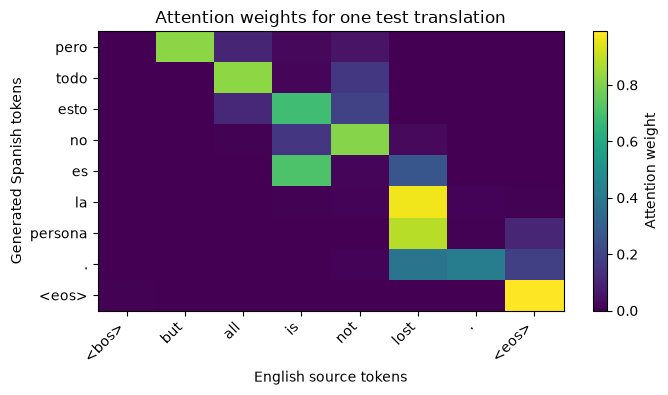

In [15]:
@torch.no_grad()
def translate_with_attention(
    model,
    text,
    source_vocab,
    target_vocab,
    max_length,
):
    model.eval()

    source_tokens = [BOS, *word_tokenize(text), EOS]
    source_ids = torch.tensor(
        [
            source_vocab.stoi.get(token, UNK_ID)
            for token in source_tokens
        ],
        dtype=torch.long,
        device=DEVICE,
    ).unsqueeze(0)
    lengths = torch.tensor([source_ids.size(1)])

    encoder_outputs, hidden, source_mask = model.encode(
        source_ids,
        lengths,
    )
    current = torch.tensor(
        [[BOS_ID]],
        dtype=torch.long,
        device=DEVICE,
    )

    predicted_ids = []
    target_labels = []
    attention_rows = []

    for _ in range(max_length):
        logits, hidden, attention = model.decode(
            current,
            hidden,
            encoder_outputs,
            source_mask,
        )
        current = logits[:, -1].argmax(-1, keepdim=True)
        token = current.item()

        attention_rows.append(attention[0, -1].cpu().numpy())
        target_labels.append(target_vocab.itos[token])

        if token == EOS_ID:
            break

        predicted_ids.append(token)

    hypothesis_tokens = target_vocab.decode(predicted_ids)
    attention_matrix = np.stack(attention_rows)

    return (
        source_tokens,
        target_labels,
        hypothesis_tokens,
        attention_matrix,
    )


example_frame = splits["test"].copy()
example_frame["source_length"] = example_frame["english"].map(
    lambda text: len(word_tokenize(text))
)
candidates = example_frame[
    example_frame["source_length"].between(5, 10)
].sort_values("original_index")

example = (
    candidates.iloc[15]
    if len(candidates)
    else example_frame.sort_values("original_index").iloc[0]
)

(
    source_tokens,
    target_labels,
    hypothesis_tokens,
    attention_matrix,
) = translate_with_attention(
    attention_en_to_es["model"],
    example["english"],
    english_word_vocab,
    spanish_word_vocab,
    MAX_WORD_TOKENS + 10,
)

hypothesis = detokenize_words(hypothesis_tokens)

print("Source:", example["english"])
print("Reference:", example["spanish"])
print("Prediction:", hypothesis)

plt.figure(
    figsize=(
        max(7, 0.65 * len(source_tokens)),
        max(4, 0.45 * len(target_labels)),
    )
)
plt.imshow(attention_matrix, aspect="auto")
plt.colorbar(label="Attention weight")
plt.xticks(
    range(len(source_tokens)),
    source_tokens,
    rotation=45,
    ha="right",
)
plt.yticks(
    range(len(target_labels)),
    target_labels,
)
plt.xlabel("English source tokens")
plt.ylabel("Generated Spanish tokens")
plt.title("Attention weights for one test translation")
plt.tight_layout()
plt.savefig(
    PLOT_DIR / "attention_heatmap_en_to_es.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

pd.DataFrame(
    [
        {
            "original_index": example["original_index"],
            "source": example["english"],
            "reference": example["spanish"],
            "hypothesis": hypothesis,
        }
    ]
).to_csv(
    ARTIFACT_DIR / "attention_example.csv",
    index=False,
)
